In [1]:
!pip install kaggle -q

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files

uploded = files.upload()

# Move it to the folder where Kaggle CLI expects it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured!")

Saving kaggle.json to kaggle.json
Kaggle API configured!


In [6]:
# Download PlantVillage dataset
!kaggle datasets download -d emmarex/plantdisease

# Unzip it
!unzip -q plantdisease.zip -d plantvillage

print("Done!")
!ls plantvillage/

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 99% 650M/658M [00:01<00:00, 293MB/s]
100% 658M/658M [00:01<00:00, 392MB/s]
Done!
plantvillage  PlantVillage


In [8]:
dataset_path = "plantvillage/PlantVillage"
all_classes = sorted(os.listdir(dataset_path))

print(f"Total classes: {len(all_classes)}\n")
for cls in all_classes:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    print(f"  {cls}: {count} images")

Total classes: 15

  Pepper__bell___Bacterial_spot: 997 images
  Pepper__bell___healthy: 1478 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
  Tomato_Bacterial_spot: 2127 images
  Tomato_Early_blight: 1000 images
  Tomato_Late_blight: 1909 images
  Tomato_Leaf_Mold: 952 images
  Tomato_Septoria_leaf_spot: 1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
  Tomato__Target_Spot: 1404 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
  Tomato__Tomato_mosaic_virus: 373 images
  Tomato_healthy: 1591 images


In [10]:
from sklearn.model_selection import train_test_split
import shutil

# configuration
DATASET_PATH = "plantvillage/PlantVillage"
BASE_PATH = "data"    # where I'will put train/val/test splits
IMG_SIZE =224         # MobileNetV2 expects 224x224
BATCH_SIZE = 32
SEED = 42

In [11]:
# Step 1: Collect all image paths and labels
all_images = []
all_labels = []

classes = sorted(os.listdir(DATASET_PATH))
print(f"Classes found: {len(classes)}\n")

for label in classes:
  folder = os.path.join(DATASET_PATH, label)
  for img_file in os.listdir(folder):
    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
      all_images.append(os.path.join(folder, img_file))
      all_labels.append(label)
print(f"Total images collected: {len(all_images)}")

Classes found: 15

Total images collected: 20638


In [12]:
# Step 2: Split -> 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels,
    test_size=0.2, stratify=all_labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"\nSplit summary:")
print(f"  Train : {len(X_train)} images")
print(f"  Val   : {len(X_val)} images")
print(f"  Test  : {len(X_test)} images")


Split summary:
  Train : 16510 images
  Val   : 2064 images
  Test  : 2064 images


In [13]:
# Step 3: Copying images into train/val/test folder
def copy_images(image_paths, labels, split_name):
  for img_path, label in zip(image_paths, labels):
    dest_dir = os.path.join(BASE_PATH, split_name, label)
    os.makedirs(dest_dir, exist_ok=True)
    shutil.copy(img_path, dest_dir)

print("\nCopying files (takes ~1 min)...")
copy_images(X_train, y_train, "train")
copy_images(X_val,   y_val,   "val")
copy_images(X_test,  y_test,  "test")
print("Done! Folder structure ready.")


Copying files (takes ~1 min)...
Done! Folder structure ready.


In [14]:
# ------Data Generators-------------

# Training generator - includes augmentation
# Augmentation = artificially creates variations of images
# so the model doesn't just memorize, it actually learns

train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalize pixels from 0-255 to 0-1
    rotation_range=20,           # randomly rotate images up to 20 degrees
    width_shift_range=0.2,       # randomly shift image left/right
    height_shift_range=0.2,      # randomly shift image up/down
    shear_range=0.2,             # tilt the image slightly
    zoom_range=0.2,              # randomly zoom in/out
    horizontal_flip=True,        # randomly flip image left-right
    fill_mode='nearest'          # fill any empty pixels after transformation
)

# Val and test generators - NO augmentation, just normalize
# We don't augment these because we want real evaluation
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from folders
train_generator = train_datagen.flow_from_directory(
    "data/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # one-hot encoded labels for 15 classes
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    "data/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                # no shuffle for validation
)

test_generator = test_datagen.flow_from_directory(
    "data/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


print(f"Class indices:\n")
for cls, idx in train_generator.class_indices.items():
    print(f"  {idx:2d} : {cls}")


Found 16510 images belonging to 15 classes.
Found 2064 images belonging to 15 classes.
Found 2064 images belonging to 15 classes.
Class indices:

   0 : Pepper__bell___Bacterial_spot
   1 : Pepper__bell___healthy
   2 : Potato___Early_blight
   3 : Potato___Late_blight
   4 : Potato___healthy
   5 : Tomato_Bacterial_spot
   6 : Tomato_Early_blight
   7 : Tomato_Late_blight
   8 : Tomato_Leaf_Mold
   9 : Tomato_Septoria_leaf_spot
  10 : Tomato_Spider_mites_Two_spotted_spider_mite
  11 : Tomato__Target_Spot
  12 : Tomato__Tomato_YellowLeaf__Curl_Virus
  13 : Tomato__Tomato_mosaic_virus
  14 : Tomato_healthy


In [15]:
# Building actual model
NUM_CLASSES = 15

# --- Step 1: Load MobileNetV2 without its top classifier
# include_top=False means we remove the last layer
# (it was trained for 10000 ImaeNet classes, we need 15)
# weights='imagenet' means we load all the pretrained knowledge

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# --- Step 2: Freeze the base model ---
# Freezing = don't update these weights during training
# We want to keep MobileNetV2's learned features intact
# and only train our new classifier on top

base_model.trainable = False

# --- Step 3: Build our classifier on top ---
x = base_model.output
x = GlobalAveragePooling2D()(x)   # converts feature maps to a flat vector
x = Dense(128, activation='relu')(x)  # fully connected layer, learns combinations
x = Dropout(0.3)(x)               # randomly drops 30% of neurons during training
                                   # prevents overfitting

output = Dense(NUM_CLASSES, activation='softmax')(x)  # 15 outputs, probabilities sum to 1

model = Model(inputs=base_model.input, outputs=output)

# --- Step 4: Compile ---
model.compile(
    optimizer='adam',                          # adaptive learning rate optimizer
    loss='categorical_crossentropy',           # standard loss for multi-class
    metrics=['accuracy']
)

# --- Step 5: Summary ---
total = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen     = total - trainable

print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}  ← only these update during training")
print(f"Frozen parameters   : {frozen:,}  ← MobileNetV2 backbone, stays fixed")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters    : 2,423,887
Trainable parameters: 165,903  ← only these update during training
Frozen parameters   : 2,257,984  ← MobileNetV2 backbone, stays fixed


In [16]:
# Training the model

# 1. Stop training early if val_accuracy stops improving
early_stop = EarlyStopping(
     monitor='val_accuracy',    # watch validation accuracy
    patience=5,                # stop if no improvement for 5 epochs
    restore_best_weights=True  # roll back to best weights when stopped
)

# 2. Save the best model automatically during training
checkpoint = ModelCheckpoint(
    'best_model.keras',   # save location
    monitor='val_accuracy',
    save_best_only=True,  # only overwrite if this epoch is better
    verbose=1
)

# 3. Reduce learning rate if training plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,                # multiply learning rate by 0.2 when triggered
    patience=3,                # trigger after 3 epochs of no improvement
    min_lr=1e-7,               # never go below this learning rate
    verbose=1
)

# --- Traininig ---
print("Starting training...\n")

history = model.fit(
    train_generator,
    epochs=20,        # maximum 20 epochs (early stopping may ent it sooner)
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("\nTraining complete!")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Starting training...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5992 - loss: 1.2587
Epoch 1: val_accuracy improved from -inf to 0.84545, saving model to best_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 244s 436ms/step - accuracy: 0.5994 - loss: 1.2580 - val_accuracy: 0.8454 - val_loss: 0.4911 - learning_rate: 0.0010
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.8063 - loss: 0.5741
Epoch 2: val_accuracy improved from 0.84545 to 0.85610, saving model to best_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 193s 374ms/step - accuracy: 0.8063 - loss: 0.5741 - val_accuracy: 0.8561 - val_loss: 0.4151 - learning_rate: 0.0010
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8408 - loss: 0.4716
Epoch 3: val_accuracy improved from 0.85610 to 0.88178, saving model to best_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 194s 376ms/step - accuracy: 0.8408 - loss: 0.4716 - val_accuracy: 0.8818 - val_loss: 0.3529 - learning_rate: 0.0010
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━

Evaluating on test set...

65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.9378 - loss: 0.1911

Test Accuracy : 0.9205 (92.05%)
Test Loss     : 0.2488
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step

Per-class Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.97      0.97       100
                     Pepper__bell___healthy       0.97      0.99      0.98       148
                      Potato___Early_blight       0.99      0.95      0.97       100
                       Potato___Late_blight       0.95      0.91      0.93       100
                           Potato___healthy       0.83      1.00      0.91        15
                      Tomato_Bacterial_spot       0.92      0.95      0.94       213
                        Tomato_Early_blight       0.86      0.78      0.82       100
                         Tomato_Late_blight       0.94      0.93      0.94       191
              

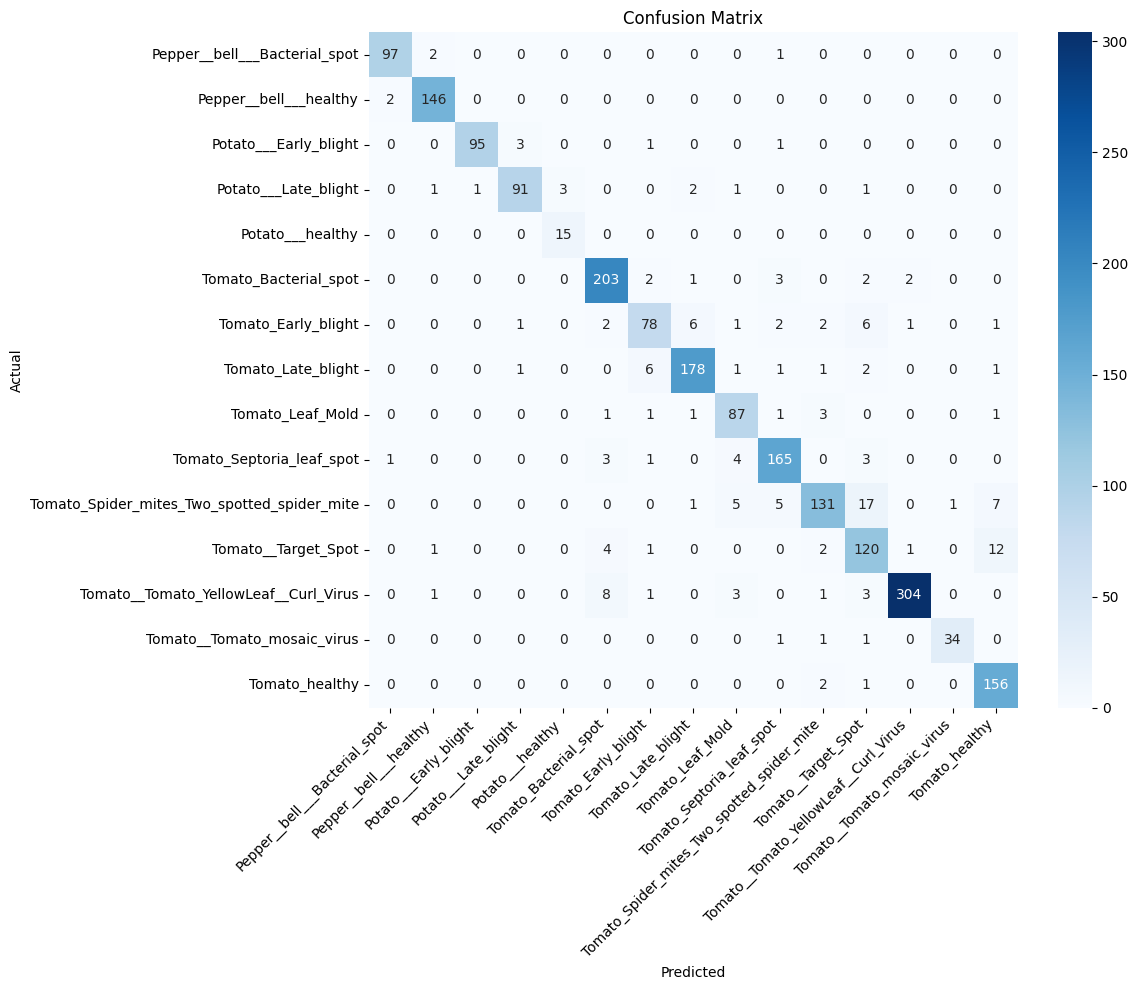

In [18]:
# Evaluate on the test set.

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- Load the best saved model
from tensorflow.keras.models import load_model
best_model = load_model('best_model.keras')

# --- Evaluating on test set
print("Evaluating on test set...\n")
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss     : {test_loss:.4f}")

# --- Pre-class breakdown
# Get true labels and predictions
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("\nPer-class Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# saving the class names mapping
import json

# Save class indices mapping
class_indices = train_generator.class_indices

# Flip it: {0: 'class_name'} instead of {'class_name': 0}
index_to_class = {v: k for k, v in class_indices.items()}

with open('class_indices.json', 'w') as f:
  json.dump(index_to_class, f, indent=2)

print("Saved class_indices.json:")
print(json.dumps(index_to_class, indent=2))

Saved class_indices.json:
{
  "0": "Pepper__bell___Bacterial_spot",
  "1": "Pepper__bell___healthy",
  "2": "Potato___Early_blight",
  "3": "Potato___Late_blight",
  "4": "Potato___healthy",
  "5": "Tomato_Bacterial_spot",
  "6": "Tomato_Early_blight",
  "7": "Tomato_Late_blight",
  "8": "Tomato_Leaf_Mold",
  "9": "Tomato_Septoria_leaf_spot",
  "10": "Tomato_Spider_mites_Two_spotted_spider_mite",
  "11": "Tomato__Target_Spot",
  "12": "Tomato__Tomato_YellowLeaf__Curl_Virus",
  "13": "Tomato__Tomato_mosaic_virus",
  "14": "Tomato_healthy"
}


In [20]:
from google.colab import files

files.download('best_model.keras')
files.download('class_indices.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>